<a href="https://colab.research.google.com/github/AntonioAt/srp-autonomous-optimizer/blob/main/SRP_Diagnostic_Core.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
!git clone https://github.com/AntonioAt/srp-autonomous-optimizer.git
%cd srp-autonomous-optimizer
!python main.py

Cloning into 'srp-autonomous-optimizer'...
remote: Enumerating objects: 59, done.
remote: Counting objects: 100% (59/59), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 59 (delta 15), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (59/59), 30.24 KiB | 15.12 MiB/s, done.
Resolving deltas: 100% (15/15), done.
/content/srp-autonomous-optimizer/srp-autonomous-optimizer/srp-autonomous-optimizer/srp-autonomous-optimizer/srp-autonomous-optimizer
 SRP AUTONOMOUS CONTROL EDGE-SERVER INITIALIZED

[BETA-07] Pipeline Active. Current SPM: 10.0
[BETA-07] Logging data to srp_operation_log.csv
[BETA-07] Listening to high-frequency telemetry stream...

Stroke 0021 | ML Class: FLUID_POUND    

[WARNING] Well BETA-07: Chronic Fluid Pound detected. Avg Severity: 31.2%
[ENGINEERING] Calculating dynamic mitigation strategy...
 > Warning: Target drop is too aggressive. Applying damped step of max 1.5 SPM.
 > Current Capacity (10.0 SPM) : 262.4 BPD
 > Target Capacity 

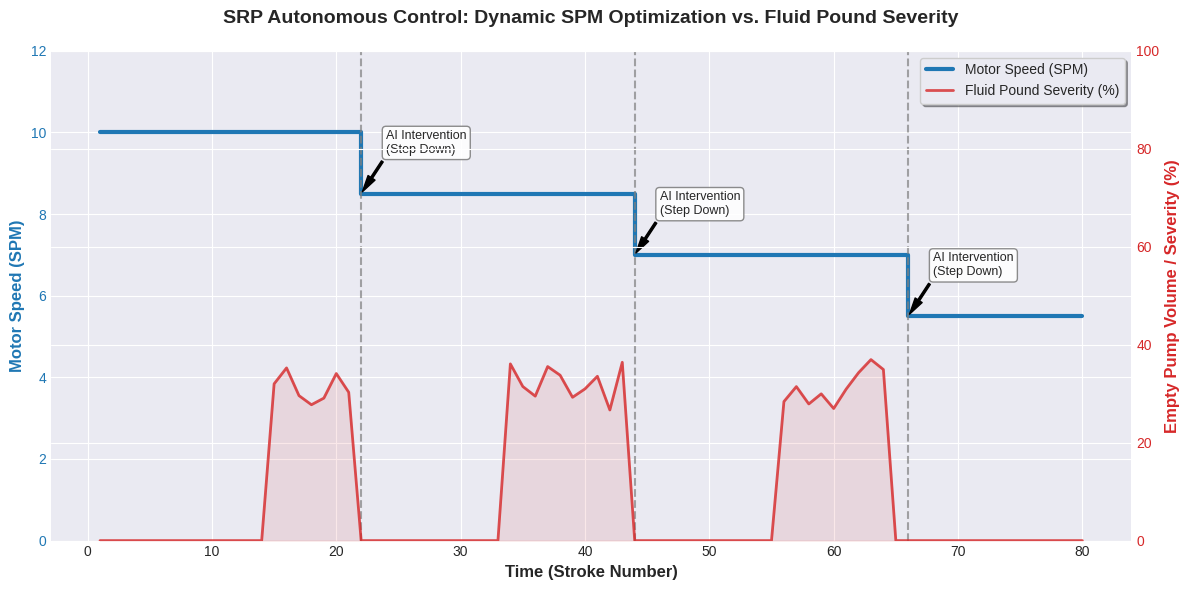

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def render_executive_dashboard(log_file="srp_operation_log.csv"):
    """
    Reads the operation log generated by main.py and renders a dual-axis executive dashboard.
    """
    if not os.path.exists(log_file):
        print(f"[ERROR] File log '{log_file}' tidak ditemukan. Pastikan main.py sudah selesai dijalankan.")
        return

    # Membaca data log asli dari main.py
    df = pd.read_csv(log_file)

    # Inisialisasi Plot
    plt.style.use('seaborn-v0_8-darkgrid')
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Judul
    plt.title('SRP Autonomous Control: Dynamic SPM Optimization vs. Fluid Pound Severity',
              fontsize=14, fontweight='bold', pad=20)

    # --------------------------------------------------------------------------
    # SUMBU Y KIRI: Kecepatan Motor (SPM) - Tindakan AI
    # --------------------------------------------------------------------------
    color1 = '#1f77b4' # Biru standar
    ax1.set_xlabel('Time (Stroke Number)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Motor Speed (SPM)', color=color1, fontsize=12, fontweight='bold')
    line1, = ax1.plot(df['stroke_number'], df['current_spm'],
                      color=color1, linewidth=3, label='Motor Speed (SPM)', drawstyle='steps-post')
    ax1.tick_params(axis='y', labelcolor=color1)

    # Beri sedikit ruang kosong di atas batas maksimum SPM agar rapi
    max_spm = df['current_spm'].max()
    ax1.set_ylim(0, max_spm + 2)

    # --------------------------------------------------------------------------
    # SUMBU Y KANAN: Keparahan Fluid Pound - Kondisi Sumur
    # --------------------------------------------------------------------------
    ax2 = ax1.twinx()
    color2 = '#d62728' # Merah bahaya
    ax2.set_ylabel('Empty Pump Volume / Severity (%)', color=color2, fontsize=12, fontweight='bold')

    line2, = ax2.plot(df['stroke_number'], df['pound_severity_pct'],
                      color=color2, linewidth=2, alpha=0.8, label='Fluid Pound Severity (%)')
    ax2.fill_between(df['stroke_number'], df['pound_severity_pct'], 0, color=color2, alpha=0.1)
    ax2.tick_params(axis='y', labelcolor=color2)
    ax2.set_ylim(0, 100)

    # --------------------------------------------------------------------------
    # ANOTASI (Highlight Tindakan Intervensi AI)
    # --------------------------------------------------------------------------
    # Mencari titik di mana SPM mengalami penurunan (Intervensi AI)
    intervention_points = df[df['current_spm'].diff() < 0]['stroke_number'].tolist()

    for pt in intervention_points:
        spm_val = df[df['stroke_number'] == pt]['current_spm'].values[0]
        ax1.axvline(x=pt, color='grey', linestyle='--', alpha=0.7)
        ax1.annotate('AI Intervention\n(Step Down)',
                     xy=(pt, spm_val),
                     xytext=(pt + 2, spm_val + 1),
                     arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=6),
                     fontsize=9, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9))

    # Menggabungkan Legenda
    lines = [line1, line2]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper right', frameon=True, shadow=True)

    fig.tight_layout()
    plt.show()

# Jalankan fungsi visualisasi
render_executive_dashboard()

In [10]:
from google.colab import files
files.download('srp_operation_log.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>